In [1]:
# library imports

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import cv2
import os 
import warnings
warnings.filterwarnings("ignore")

# Find Model 

# start with yolo neno version

In [ ]:
from ultralytics import YOLO

#---------------------------------------------------
#assign the model
#---------------------------------------------------

model = YOLO("yolo26n.pt")

#---------------------------------------------------
#start training the model
#---------------------------------------------------

result = model.train(data="data.yml" , epochs=10 , batch=32 , imgsz=640 , exist_ok=True)

KeyboardInterrupt: 

* Epoch used only 10 
* exists_ok = True , if the train model file exists the model training will start with that file can not create another file
* used standard img size for yolo 640

In [ ]:
#---------------------------------------------------
#print the number of images in train and val folders
#---------------------------------------------------

train_path = "./archive/custom_dataset/images/train"
val_path = "./archive/custom_dataset/images/val"

print("Train images:", len(os.listdir(train_path)))
print("Val images:", len(os.listdir(val_path)))

Train images: 977
Val images: 246


In [ ]:
#---------------------------------------------------
#try a different version of yolo model
#---------------------------------------------------

model_medium = YOLO("yolo26m.pt")
result_medium = model_medium.train(data="data.yml" , epochs=10 , batch=32 , imgsz=640 , exist_ok=True)

* neno yolo model work reletively week to medium version check with large model

In [ ]:
#---------------------------------------------------
#lager version of yolo model
#---------------------------------------------------

model_large = YOLO("yolo26l.pt")
result_large = model_large.train(data="data.yml" , epochs=50 , batch=32 , imgsz=640 , exist_ok=True)

New https://pypi.org/project/ultralytics/8.4.80 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.75  Python-3.11.9 torch-2.12.1+cpu CPU (AMD Ryzen 3 3250U with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-4, nb

: 

# Large model work well check with validation 

In [36]:
!yolo val model="./runs/detect/train-7/best.pt" data="data.yml" task="detect"

^C


# Now try detectron models

In [ ]:
#-------------------------------------------------------------------
# install Detectron2 model
#-------------------------------------------------------------------

!python -m pip install pyyaml==5.1
import os ,sys , distutils.core
!git clone "https://github.com/facebookresearch/detectron2"
dist = distutils.core.run_setup("./detectron2/setup.py")
!python -m pip install {" ".join([f"'{x}'" for x in dist.install_requires])}
sys.path.insert(0 , os.path.abspath("./detectron2"))


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
fatal: destination path 'detectron2' already exists and is not an empty directory.
The system cannot find the file specified.


In [ ]:
#-------------------------------------------------------------------
# check version
#-------------------------------------------------------------------

import torch , detectron2
!nvcc --version
torch_ver = ".".join(torch.__version__.split("+")[:1])
print("torch version:", torch_ver)
detectron2_ver = detectron2.__version__
print("detectron2 version:", detectron2_ver)
cuda_ver = torch.__version__.split("+")[-1]
print("cuda version:", cuda_ver)

torch version: 2.12.1
detectron2 version: 0.6
cuda version: cpu


'nvcc' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
import detectron2              
from detectron2 import model_zoo            # model zoo 
from detectron2.engine import DefaultTrainer , DefaultPredictor # used to train and predict the model
from detectron2.config import get_cfg      # used to get the configuration of the model
from detectron2.utils.visualizer import Visualizer    # used to visualize the predictions 
from detectron2.data import MetadataCatalog , DatasetCatalog   # used to register the dataset and get the metadata of the dataset

In [ ]:
#---------------------------------------------------
#register the dataset
#---------------------------------------------------

from detectron2.data.datasets import register_coco_instances
register_coco_instances("register_train" ,{} , "./archive/custom_dataset/annotations/instances_train.json" , "./archive/custom_dataset/images/train")
register_coco_instances("register_val" ,{} , "./archive/custom_dataset/annotations/instances_val.json" , "./archive/custom_dataset/images/val")

In [ ]:
#---------------------------------------------------
#get the metadata and dataset
#---------------------------------------------------

metadata = MetadataCatalog.get("register_train")
dataset = DatasetCatalog.get("register_train")

Loaded 977 images in COCO format from ./archive/custom_dataset/annotations/instances_train.json


# start with Faster Rcnn resnet 50 model

that is Faster Rcnn model and resnet 50 used a a backbone of model

In [ ]:
#---------------------------------------------------
#create model 
#---------------------------------------------------

cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"))
cfg.DATASETS.TRAIN = ("register_train",)
cfg.DATASETS.VALID = ("register_val",)
cfg.DATALOADER.NUM_WORKERS = 2
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml")
cfg.SOLVER.IMS_PER_BATCH = 2
cfg.MODEL.DEVICE = "cpu"
cfg.SOLVER.BASE_LR = 0.00025
cfg.SOLVER.MAX_ITER = 1000

In [ ]:
#---------------------------------------------------
#start training the model
#---------------------------------------------------

os.makedirs(cfg.OUTPUT_DIR , exist_ok=True)
trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=False)
trainer.train()

Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res2): Sequential(
        (0): Bottlene

SOLVER.STEPS contains values larger than SOLVER.MAX_ITER. These values will be ignored.


[DetectionCheckpointer] Loading from https://dl.fbaipublicfiles.com/detectron2/COCO-Detection/faster_rcnn_R_50_FPN_3x/137849458/model_final_280758.pkl ...


model_final_280758.pkl: 167MB [08:46, 318kB/s]                               


Successfully downloaded C:\Users\HP/.torch/iopath_cache\detectron2/COCO-Detection/faster_rcnn_R_50_FPN_3x/137849458\model_final_280758.pkl. 167266879 bytes.
URL https://dl.fbaipublicfiles.com/detectron2/COCO-Detection/faster_rcnn_R_50_FPN_3x/137849458/model_final_280758.pkl cached in C:\Users\HP/.torch/iopath_cache\detectron2/COCO-Detection/faster_rcnn_R_50_FPN_3x/137849458\model_final_280758.pkl
[Checkpointer] Loading from C:\Users\HP/.torch/iopath_cache\detectron2/COCO-Detection/faster_rcnn_R_50_FPN_3x/137849458\model_final_280758.pkl ...
Reading a file from 'Detectron2 Model Zoo'
Starting training from iteration 0


W0629 11:18:14.908000 5008 site-packages\torch\fx\_symbolic_trace.py:56] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


Overall training speed: 5 iterations in 0:06:42 (80.5159 s / it)
Total training time: 0:06:42 (0:00:00 on hooks)
 eta: 21:52:05  iter: 7  total_loss: 0.8194  loss_cls: 0.6283  loss_box_reg: 0.1319  loss_rpn_cls: 0.02264  loss_rpn_loc: 0.01377    time: 77.4504  last_time: 75.4104  data_time: 2.0308  last_data_time: 0.0113   lr: 1.7485e-06  


ModuleNotFoundError: No module named 'tensorboard'

# Evalute the model

In [19]:
from detectron2.data import build_detection_test_loader
from detectron2.evaluation import COCOEvaluator , inference_on_dataset
evaluator = COCOEvaluator("register_val" , output_dir="./output")
val_loader = build_detection_test_loader(cfg , "register_val")
print(inference_on_dataset(trainer.model , val_loader , evaluator))

Fast COCO eval is not built. Falling back to official COCO eval.
Loaded 246 images in COCO format from ./archive/custom_dataset/annotations/instances_val.json
Distribution of instances among all 5 categories:
|   category    | #instances   |   category    | #instances   |   category    | #instances   |
|:-------------:|:-------------|:-------------:|:-------------|:-------------:|:-------------|
|  No Accident  | 428          | Minor Accid.. | 104          | Moderate Ac.. | 66           |
| Severe Acci.. | 76           | Totaled Veh.. | 82           |               |              |
|     total     | 756          |               |              |               |              |
[DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
Serializing 246 elements to byte tensors and concatenating them all ...
Serialized dataset ta

KeyboardInterrupt: 

# Yolo large model work well 

* go with yolo large model you can try with auther detectron model

# Save the yolo model

In [ ]:
#---------------------------------------------------
#export the model to onnx format
#---------------------------------------------------

!yolo export model="./runs/detect/train-7/best.pt" format="onnx"

# Test the yolo model

In [ ]:
# Load ONNX model
model = YOLO("best.onnx")   # Replace with your ONNX file path

# Test image
result = model.predict(
    source="./archive/custom_dataset/images/train/10_flip70.jpg",  # Replace with your image
    conf=0.25,
    save=False
)

# Display prediction
img = result[0].plot()

plt.figure(figsize=(10, 8))
plt.imshow(img[:, :, ::-1])   # BGR -> RGB
plt.axis("off")
plt.title("Prediction")
plt.show()

WARNING Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify', 'pose', 'obb' or 'semantic'.
Loading best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.27.0 with CPUExecutionProvider

image 1/1 c:\Users\HP\car_accident_detection\archive\custom_dataset\images\val\frame00241_sb_70.jpg: 640x640 5 No Accidents, 1 Severe Accident, 1 Totaled Vehicle, 2083.4ms
Speed: 6.6ms preprocess, 2083.4ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)


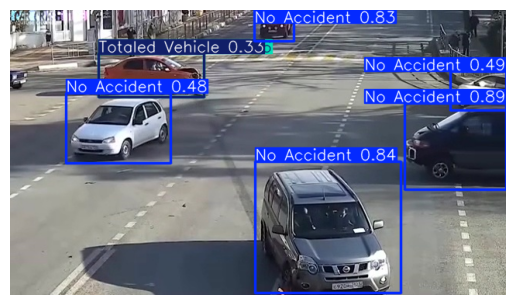


image 1/1 c:\Users\HP\car_accident_detection\archive\custom_dataset\images\val\test20_19.jpg: 640x640 4 No Accidents, 1 Minor Accident, 1 Moderate Accident, 2236.0ms
Speed: 43.7ms preprocess, 2236.0ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)


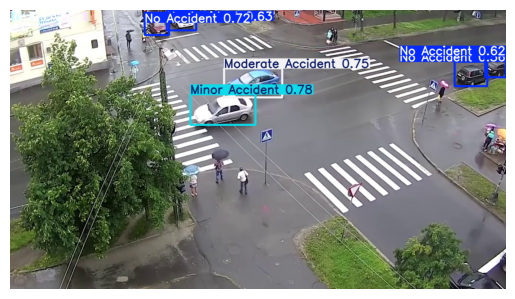


image 1/1 c:\Users\HP\car_accident_detection\archive\custom_dataset\images\val\frame_9300.jpg: 640x640 1 No Accident, 1 Minor Accident, 2 Moderate Accidents, 2012.6ms
Speed: 5.0ms preprocess, 2012.6ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)


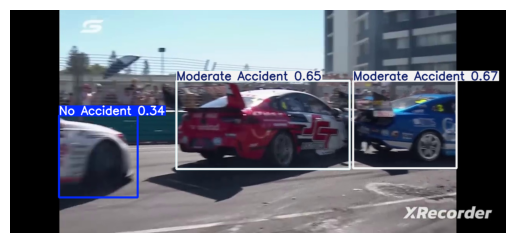


image 1/1 c:\Users\HP\car_accident_detection\archive\custom_dataset\images\val\Screenshot 2023-08-17 002857.jpg: 640x640 1 Totaled Vehicle, 3033.1ms
Speed: 35.1ms preprocess, 3033.1ms inference, 6.7ms postprocess per image at shape (1, 3, 640, 640)


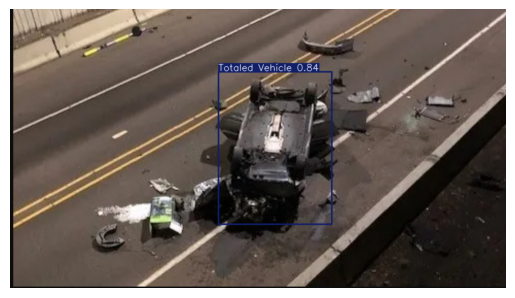


image 1/1 c:\Users\HP\car_accident_detection\archive\custom_dataset\images\val\Screenshot 2023-08-16 234607_flip50.jpg: 640x640 1 Moderate Accident, 4542.8ms
Speed: 11.8ms preprocess, 4542.8ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)


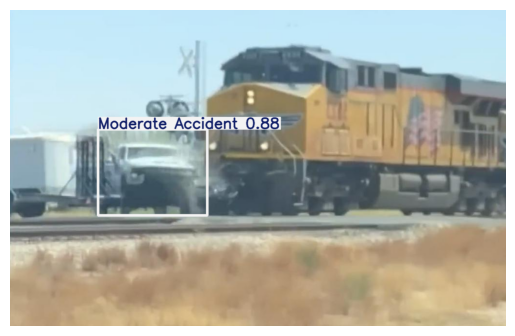

In [19]:
# predict random 5 img and show the result

import random

val_path = "./archive/custom_dataset/images/val"
# img_path = os.listdir(val_path)
image_files = [f for f in os.listdir(val_path) if f.endswith((".jpg", ".jpeg", ".png"))]
img = random.sample(image_files, 5)
model = YOLO("best.onnx")

for i in img:
    result = model.predict(source = os.path.join(val_path, i) , save=False)
    
    pred = result[0].plot()
    plt.imshow(pred[: ,: , ::-1])
    plt.axis("off")
    plt.show()